<a href="https://colab.research.google.com/github/Anthea05/Anthea_machine-learning/blob/main/JS04/JS04_Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

In [2]:
URL = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
try:
    df = pd.read_csv('insurance.csv')      # dipakai kalau file sudah ada di folder yang sama
except FileNotFoundError:
    df = pd.read_csv(URL)                  # kalau belum ada, ambil langsung dari GitHub

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
print('Ukuran data        :', df.shape)
print('Total missing value:', df.isna().sum().sum())
print('Baris duplikat     :', df.duplicated().sum())

# Hapus duplikat supaya baris yang sama tidak muncul di data latih dan data uji sekaligus
df = df.drop_duplicates().reset_index(drop=True)
print('Ukuran setelah drop duplikat:', df.shape)

Ukuran data        : (1338, 7)
Total missing value: 0
Baris duplikat     : 1
Ukuran setelah drop duplikat: (1337, 7)


In [4]:
df.describe().round(2)

,age,bmi,children,charges
count,1337.00,1337.00,1337.00,1337.00
mean,39.22,30.66,1.10,13279.12
std,14.04,6.10,1.21,12110.36
min,18.00,15.96,0.00,1121.87
25%,27.00,26.29,0.00,4746.34
50%,39.00,30.40,1.00,9386.16
75%,51.00,34.70,2.00,16657.72
max,64.00,53.13,5.00,63770.43


In [5]:
for col in ['sex', 'smoker', 'region']:
    print(df[col].value_counts(), '\n')

sex
male      675
female    662
Name: count, dtype: int64 

smoker
no     1063
yes     274
Name: count, dtype: int64 

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64 



In [6]:
df.groupby('smoker')['charges'].agg(['count', 'mean', 'median']).round(0)

,count,mean,median
smoker,,,
no,1063,8441.0,7346.0
yes,274,32050.0,34456.0


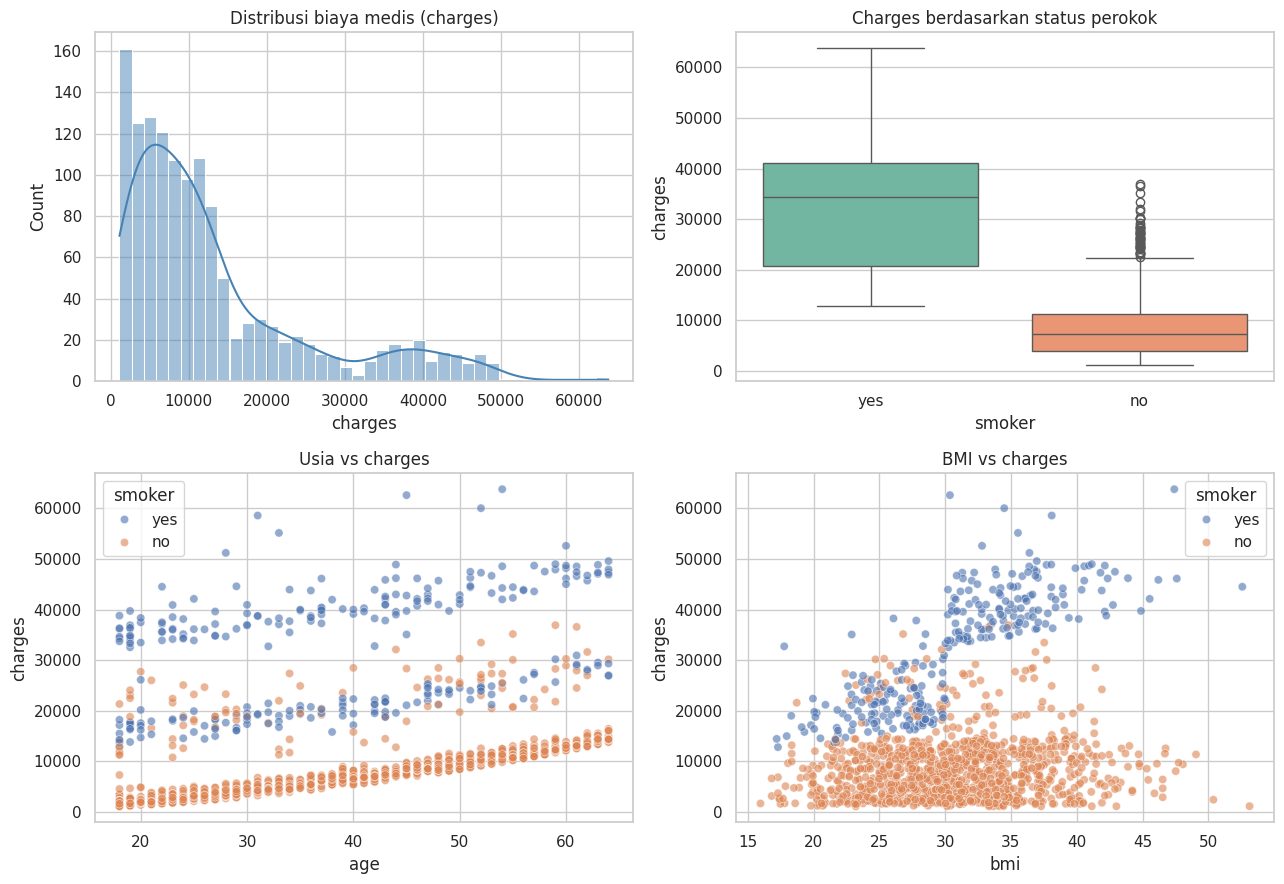

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df['charges'], bins=40, kde=True, ax=ax[0, 0], color='steelblue')
ax[0, 0].set_title('Distribusi biaya medis (charges)')

sns.boxplot(data=df, x='smoker', y='charges', hue='smoker', legend=False, ax=ax[0, 1], palette='Set2')
ax[0, 1].set_title('Charges berdasarkan status perokok')

sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.6, ax=ax[1, 0])
ax[1, 0].set_title('Usia vs charges')

sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.6, ax=ax[1, 1])
ax[1, 1].set_title('BMI vs charges')

plt.tight_layout()
plt.show()

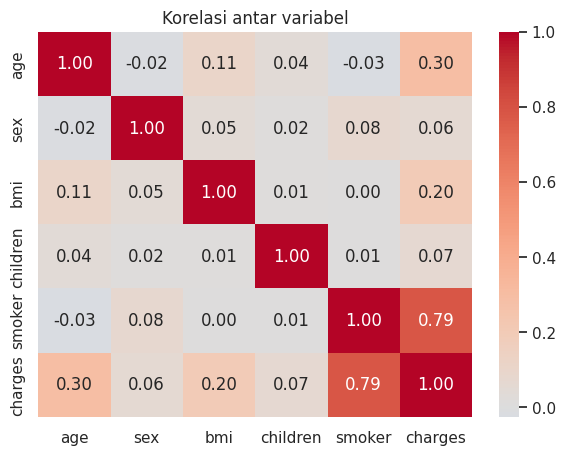

In [8]:
corr_df = df.copy()
corr_df['smoker'] = (corr_df['smoker'] == 'yes').astype(int)
corr_df['sex'] = (corr_df['sex'] == 'male').astype(int)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_df[['age', 'sex', 'bmi', 'children', 'smoker', 'charges']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasi antar variabel')
plt.show()

In [9]:
target = 'charges'
num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

X = df[num_cols + cat_cols]
y = df[target]

print('Fitur  :', list(X.columns))
print('Target :', target)

Fitur  : ['age', 'bmi', 'children', 'sex', 'smoker', 'region']
Target : charges


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=X['smoker'])

print('Data latih:', X_train.shape, '| Data uji:', X_test.shape)
print('Proporsi perokok latih:', round((X_train['smoker'] == 'yes').mean(), 3))
print('Proporsi perokok uji  :', round((X_test['smoker'] == 'yes').mean(), 3))

Data latih: (1069, 6) | Data uji: (268, 6)
Proporsi perokok latih: 0.205
Proporsi perokok uji  : 0.205


In [11]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

preprocessor.fit(X_train)
X_train_prep = pd.DataFrame(preprocessor.transform(X_train),
                            columns=preprocessor.get_feature_names_out())
display(X_train_prep.head())
print('Rata-rata dan simpangan baku fitur numerik setelah scaling (data latih):')
display(X_train_prep[['num__age', 'num__bmi', 'num__children']].agg(['mean', 'std']).round(3).abs())

,num__age,num__bmi,num__children,cat__sex_male,cat__smoker_yes,cat__region_northwest,cat__region_southeast,cat__region_southwest
0,0.209157,-0.959818,0.769598,0.0,0.0,1.0,0.0,0.0
1,1.775700,1.370265,-0.076801,1.0,0.0,0.0,1.0,0.0
2,0.992428,-0.220931,-0.923201,1.0,0.0,0.0,1.0,0.0
3,-0.146876,0.882057,-0.923201,1.0,0.0,0.0,1.0,0.0
4,-1.499800,1.225611,-0.923201,0.0,0.0,0.0,1.0,0.0


Rata-rata dan simpangan baku fitur numerik setelah scaling (data latih):


,num__age,num__bmi,num__children
mean,0.0,0.0,0.0
std,1.0,1.0,1.0


In [12]:
def evaluate(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {'Model': name,
            'R2': r2_score(y_true, y_pred),
            'MSE': mse,
            'RMSE': np.sqrt(mse),
            'MAE': mean_absolute_error(y_true, y_pred)}

lr = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
results = [evaluate('Multiple Linear Regression', y_test, y_pred_lr)]
pd.DataFrame(results).round(4)

,Model,R2,MSE,RMSE,MAE
0,Multiple Linear Regression,0.8205,2.587635e+07,5086.8799,3592.7926


Intercept: 9283.85


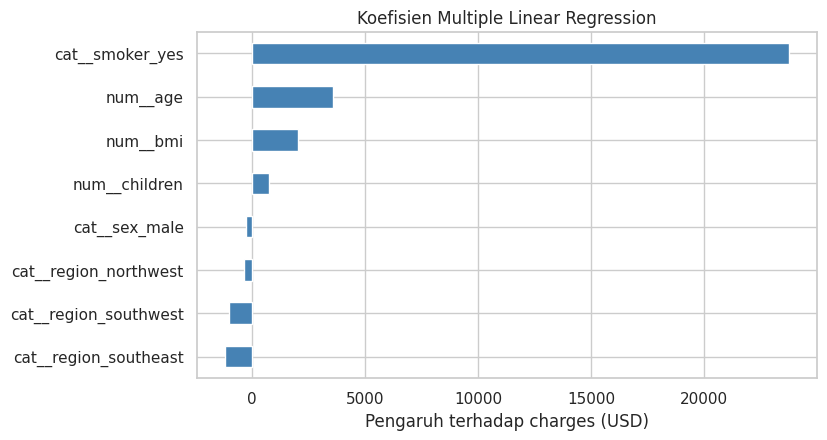

,0
cat__region_southeast,-1193.73
cat__region_southwest,-1031.82
cat__region_northwest,-361.20
cat__sex_male,-257.96
num__children,739.76
num__bmi,2012.61
num__age,3594.13
cat__smoker_yes,23750.03


In [13]:
# Koefisien model (fitur numerik dalam satuan standar deviasi)
coef = pd.Series(lr.named_steps['model'].coef_,
                 index=lr.named_steps['prep'].get_feature_names_out()).sort_values()
print('Intercept:', round(lr.named_steps['model'].intercept_, 2))

plt.figure(figsize=(8, 4.5))
coef.plot(kind='barh', color='steelblue')
plt.title('Koefisien Multiple Linear Regression')
plt.xlabel('Pengaruh terhadap charges (USD)')
plt.show()
coef.round(2)

In [14]:
cv_lr = cross_val_score(lr, X_train, y_train, cv=5, scoring='r2')
print('R2 tiap fold:', cv_lr.round(4))
print('Rata-rata   :', cv_lr.mean().round(4), '+/-', cv_lr.std().round(4))

R2 tiap fold: [0.7268 0.7348 0.7266 0.7726 0.6673]
Rata-rata   : 0.7256 +/- 0.0338


In [15]:
svr_default = Pipeline([('prep', preprocessor), ('model', SVR())])
svr_default.fit(X_train, y_train)
results.append(evaluate('SVR default', y_test, svr_default.predict(X_test)))

# 2. SVR default + target scaling
def make_svr(**params):
    return TransformedTargetRegressor(
        regressor=Pipeline([('prep', preprocessor), ('model', SVR(**params))]),
        transformer=StandardScaler())

svr_ts = make_svr()
svr_ts.fit(X_train, y_train)
results.append(evaluate('SVR default + target scaling', y_test, svr_ts.predict(X_test)))

pd.DataFrame(results).round(4)

,Model,R2,MSE,RMSE,MAE
0,Multiple Linear Regression,0.8205,2.587635e+07,5086.8799,3592.7926
1,SVR default,-0.0843,1.563038e+08,12502.1512,8106.8115
2,SVR default + target scaling,0.8951,1.512529e+07,3889.1251,2199.3030


In [16]:
param_grid = [
    {'regressor__model__kernel': ['rbf'],
     'regressor__model__C': [0.1, 1, 10, 100],
     'regressor__model__gamma': ['scale', 0.01, 0.1, 1],
     'regressor__model__epsilon': [0.01, 0.1, 0.5]},
    {'regressor__model__kernel': ['linear'],
     'regressor__model__C': [0.1, 1, 10],
     'regressor__model__epsilon': [0.01, 0.1, 0.5]},
    {'regressor__model__kernel': ['poly'],
     'regressor__model__degree': [2, 3],
     'regressor__model__C': [0.1, 1, 10],
     'regressor__model__gamma': ['scale', 0.1],
     'regressor__model__epsilon': [0.1]},
]

grid = GridSearchCV(make_svr(), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

print('Parameter terbaik :', grid.best_params_)
print('R2 CV terbaik     :', round(grid.best_score_, 4))

svr_best = grid.best_estimator_
y_pred_svr = svr_best.predict(X_test)
results.append(evaluate('SVR tuned', y_test, y_pred_svr))

Parameter terbaik : {'regressor__model__C': 100, 'regressor__model__epsilon': 0.1, 'regressor__model__gamma': 0.01, 'regressor__model__kernel': 'rbf'}
R2 CV terbaik     : 0.8237


In [18]:
cv = pd.DataFrame(grid.cv_results_)
cv['kernel'] = cv['param_regressor__model__kernel']
print('R2 CV terbaik per kernel:')
display(cv.groupby('kernel')['mean_test_score'].max().round(4).to_frame('R2 CV'))

top = cv.sort_values('rank_test_score').head(5)[['params', 'mean_test_score', 'std_test_score']]
pd.set_option('display.max_colwidth', 200)
top.round(4)

R2 CV terbaik per kernel:


,R2 CV
kernel,
linear,0.7124
poly,0.8036
rbf,0.8237


,params,mean_test_score,std_test_score
41,"{'regressor__model__C': 100, 'regressor__model__epsilon': 0.1, 'regressor__model__gamma': 0.01, 'regressor__model__kernel': 'rbf'}",0.8237,0.0345
30,"{'regressor__model__C': 10, 'regressor__model__epsilon': 0.1, 'regressor__model__gamma': 0.1, 'regressor__model__kernel': 'rbf'}",0.8223,0.0322
18,"{'regressor__model__C': 1, 'regressor__model__epsilon': 0.1, 'regressor__model__gamma': 0.1, 'regressor__model__kernel': 'rbf'}",0.8177,0.0335
26,"{'regressor__model__C': 10, 'regressor__model__epsilon': 0.01, 'regressor__model__gamma': 0.1, 'regressor__model__kernel': 'rbf'}",0.8157,0.0360
37,"{'regressor__model__C': 100, 'regressor__model__epsilon': 0.01, 'regressor__model__gamma': 0.01, 'regressor__model__kernel': 'rbf'}",0.8145,0.0377


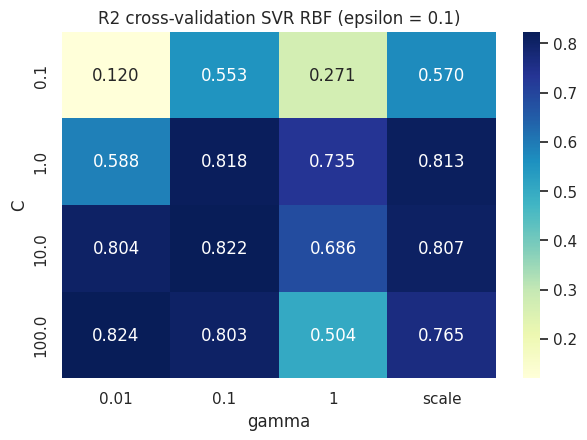

In [19]:
# Heatmap skor CV untuk kernel RBF (epsilon = 0.1), sumbu C dan gamma
rbf = cv[(cv['kernel'] == 'rbf') & (cv['param_regressor__model__epsilon'] == 0.1)].copy()
rbf['C'] = rbf['param_regressor__model__C'].astype(float)
rbf['gamma'] = rbf['param_regressor__model__gamma'].astype(str)
pivot = rbf.pivot(index='C', columns='gamma', values='mean_test_score')

plt.figure(figsize=(7, 4.5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu')
plt.title('R2 cross-validation SVR RBF (epsilon = 0.1)')
plt.show()

In [20]:
res = pd.DataFrame(results).set_index('Model')
res.round(4)

,R2,MSE,RMSE,MAE
Model,,,,
Multiple Linear Regression,0.8205,2.587635e+07,5086.8799,3592.7926
SVR default,-0.0843,1.563038e+08,12502.1512,8106.8115
SVR default + target scaling,0.8951,1.512529e+07,3889.1251,2199.3030
SVR tuned,0.9065,1.348393e+07,3672.0473,2117.1537


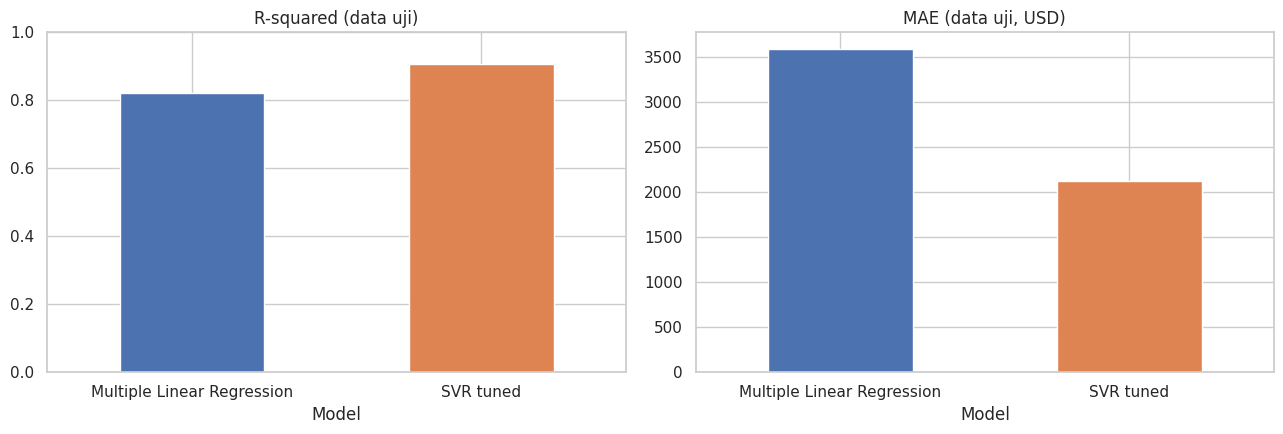

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
final = res.loc[['Multiple Linear Regression', 'SVR tuned']]
final['R2'].plot(kind='bar', ax=ax[0], color=['#4C72B0', '#DD8452'], rot=0)
ax[0].set_title('R-squared (data uji)')
ax[0].set_ylim(0, 1)
final['MAE'].plot(kind='bar', ax=ax[1], color=['#4C72B0', '#DD8452'], rot=0)
ax[1].set_title('MAE (data uji, USD)')
plt.tight_layout()
plt.show()

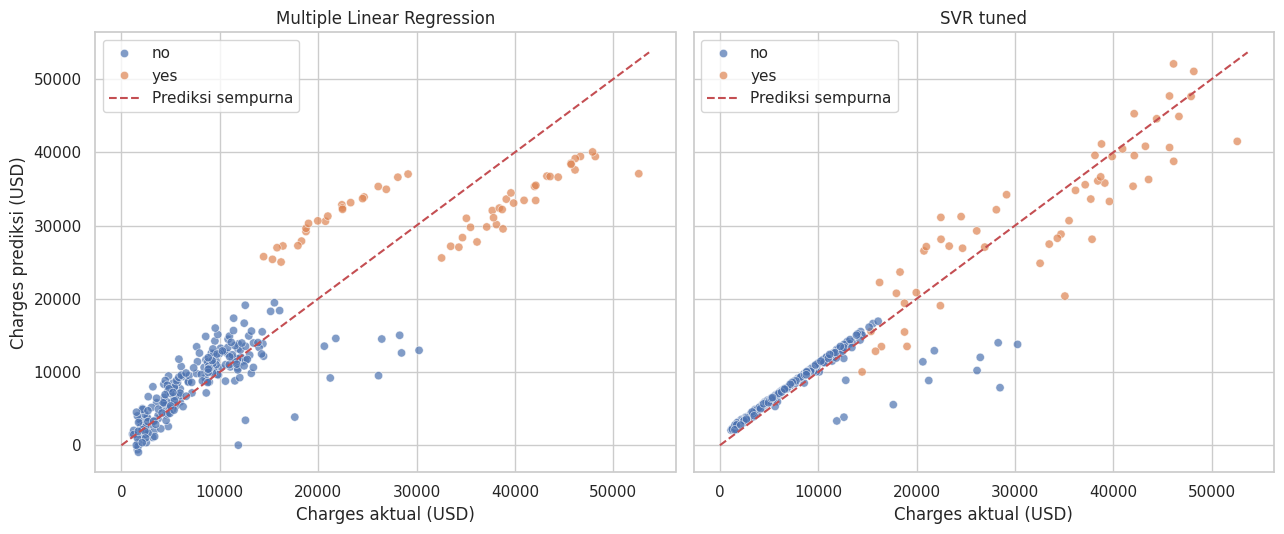

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
lim = [0, max(y_test.max(), y_pred_lr.max(), y_pred_svr.max()) * 1.02]

for a, pred, title in zip(ax, [y_pred_lr, y_pred_svr],
                          ['Multiple Linear Regression', 'SVR tuned']):
    sns.scatterplot(x=y_test, y=pred, hue=X_test['smoker'], alpha=0.7, ax=a)
    a.plot(lim, lim, 'r--', label='Prediksi sempurna')
    a.set_xlabel('Charges aktual (USD)')
    a.set_ylabel('Charges prediksi (USD)')
    a.set_title(title)
    a.legend()
plt.tight_layout()
plt.show()

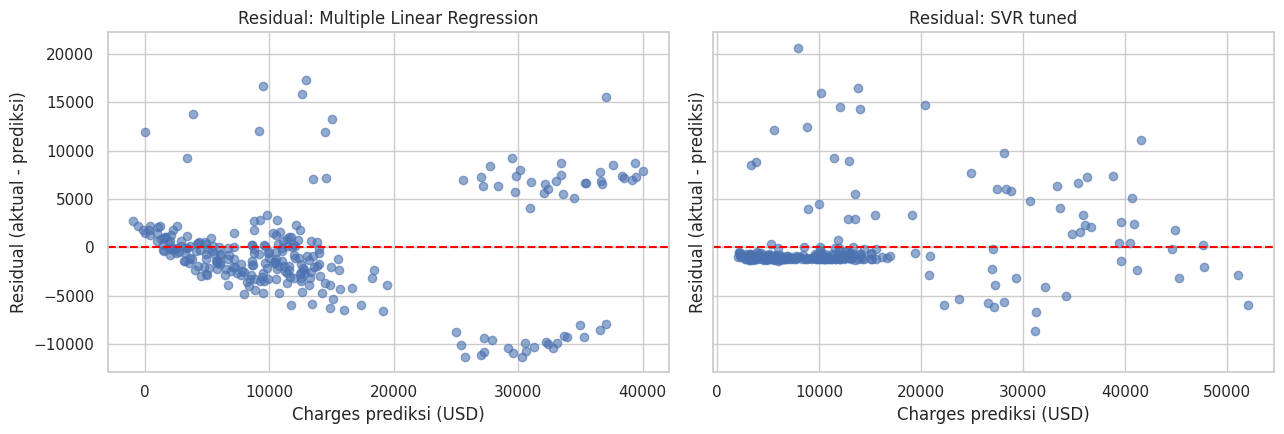

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for a, pred, title in zip(ax, [y_pred_lr, y_pred_svr],
                          ['Residual: Multiple Linear Regression', 'Residual: SVR tuned']):
    a.scatter(pred, y_test - pred, alpha=0.6)
    a.axhline(0, color='red', linestyle='--')
    a.set_xlabel('Charges prediksi (USD)')
    a.set_ylabel('Residual (aktual - prediksi)')
    a.set_title(title)
plt.tight_layout()
plt.show()

In [24]:
err = pd.DataFrame({
    'smoker': X_test['smoker'].values,
    'abs_err_LR': np.abs(y_test.values - y_pred_lr),
    'abs_err_SVR': np.abs(y_test.values - y_pred_svr)})
err.groupby('smoker').mean().round(0)

,abs_err_LR,abs_err_SVR
smoker,,
no,2369.0,1588.0
yes,8334.0,4165.0
